# CIC Heatmap (1970 vs 2022)


In [ ]:
# Load data and dependencies.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
sys.path.insert(0, str(root / 'src'))

from utils_dfs_load import merge_communes_then_arrondissements_cic

gdf = merge_communes_then_arrondissements_cic()

In [15]:
# Log-transform and keep the target years.
gdf = gdf[gdf["metric"] == "prixbien"].copy()
gdf["value_log"] = np.log(gdf["value"])
gdf = gdf[gdf["year"].isin(["1970", "2022"])].copy()


In [16]:
# Standardize per year then apply sigmoid.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

gdf["value_scaled"] = (
    gdf.groupby("year")["value_log"]
    .transform(lambda s: (s - s.mean()) / s.std(ddof=0))
)
gdf["value_sigmoid"] = sigmoid(gdf["value_scaled"])


In [17]:
mask = gdf["year"] == "1970"
m,s = gdf[mask]["value_log"].mean(), gdf[mask]["value_log"].std()

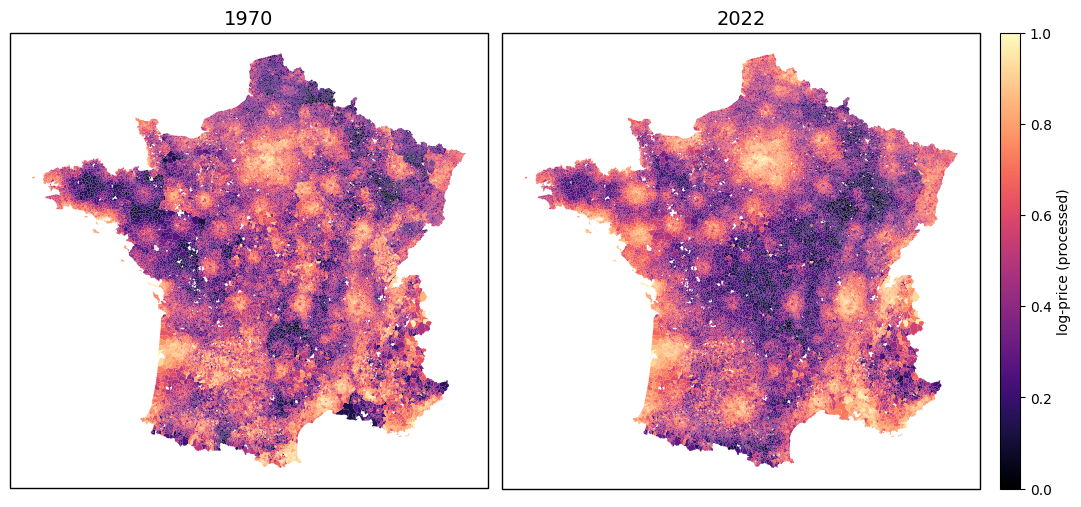

In [21]:
# Plot side-by-side heatmaps with a shared legend.
years = ["1970", "2022"]
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ax_left, ax_right = axes

vmin, vmax = 0.0, 1.0
cmap = "magma"

for ax, year in zip([ax_left, ax_right], years):
    subset = gdf[gdf["year"] == year]
    subset.plot(
        column="value_sigmoid",
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        legend=False,
        linewidth=0,
        missing_kwds={"color": "white"},
    )
    ax.set_title(f"{year}", fontsize=14)
    ax.set_axis_off()
    rect = plt.Rectangle((0, 0), 1, 1, fill=False, linewidth=1.0, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)

plt.tight_layout()

# Add a colorbar axis aligned to the right map height.
bbox = ax_right.get_position()
cax = fig.add_axes([bbox.x1 + 0.02, bbox.y0, 0.02, bbox.height])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
fig.colorbar(sm, cax=cax, label="log-price (processed)")
